<a href="https://colab.research.google.com/github/wagborba/calculadora-dfc/blob/main/colab_A6_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install pennylane

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 29.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 78.9 MB/s eta 0:00:00


=== Brick Wall (B) ===
(<Figure size 600x900 with 1 Axes>, <Axes: >)

=== Chain (C) ===
(<Figure size 1100x900 with 1 Axes>, <Axes: >)


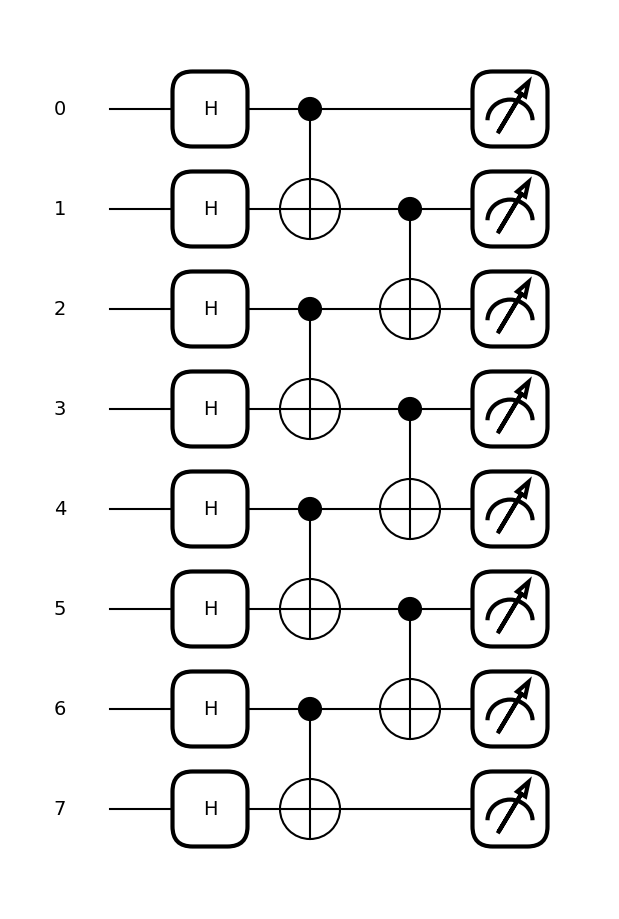

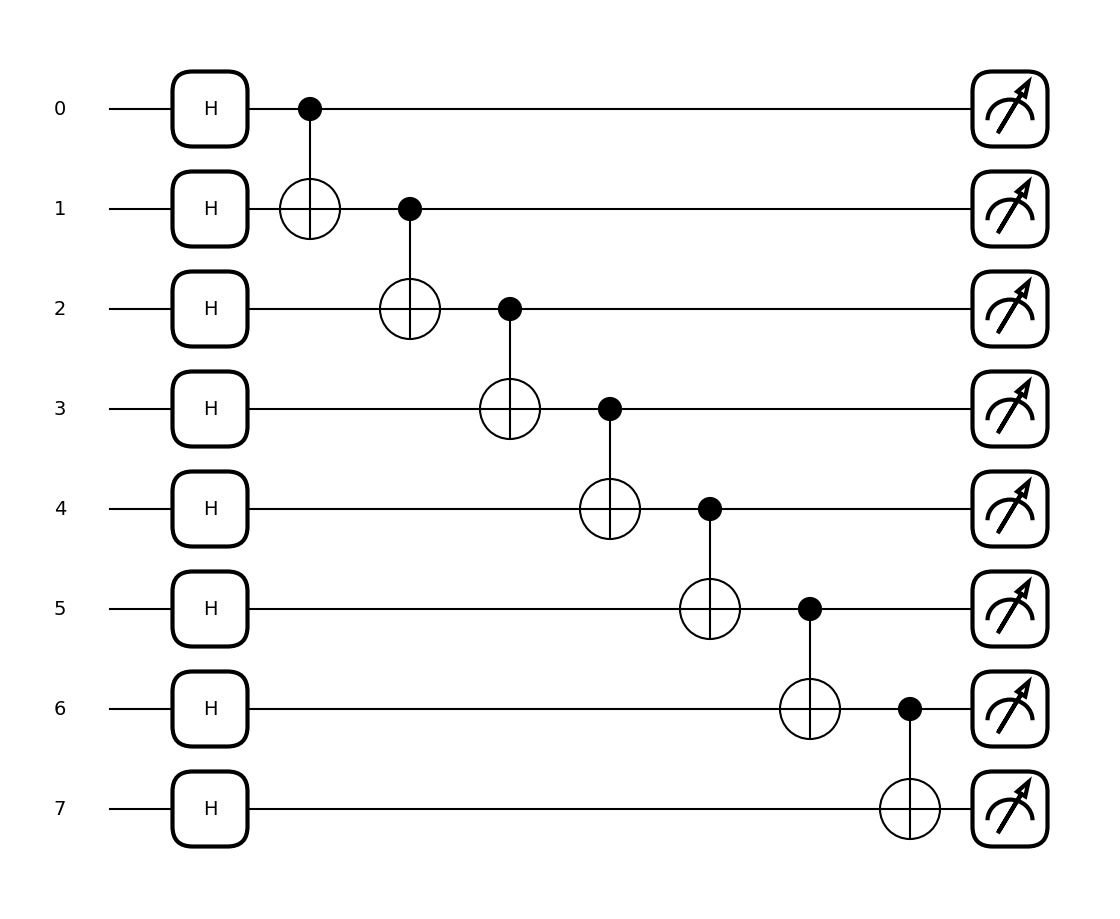

In [ ]:
import pennylane as qml
import numpy as np

# ============================================================
# Configuração básica
# ============================================================
n_qubits = 8
dev = qml.device("default.qubit", wires=n_qubits)

# ============================================================
# (B) Brick Wall: duas subcamadas de pares disjuntos
# ============================================================
def brick_wall(n):
    """
    Padrão Brick Wall:
      Subcamada 1: (0,1), (2,3), (4,5), ...
      Subcamada 2: (1,2), (3,4), (5,6), ...
    """
    # Subcamada 1 (pares começando em índices pares)
    for i in range(0, n - 1, 2):
        qml.CNOT(wires=[i, i + 1])

    # Subcamada 2 (pares começando em índices ímpares)
    for i in range(1, n - 1, 2):
        qml.CNOT(wires=[i, i + 1])


# ============================================================
# (C) Chain: todos os pares em sequência, mesma direção i -> i+1
# ============================================================
def chain(n):
    """
    Padrão Chain:
      (0,1), (1,2), (2,3), ..., (n-2,n-1)
    """
    for i in range(n - 1):
        qml.CNOT(wires=[i, i + 1])




# ============================================================
# Circuito para visualizar os padrões
# ============================================================
@qml.qnode(dev)
def circuit(pattern="brick"):
    # (opcional) coloque uma rotaçãozinha só pra não ficar tudo trivial
    for i in range(n_qubits):
        qml.Hadamard(wires=i)

    if pattern == "brick":
        brick_wall(n_qubits)
    elif pattern == "chain":
        chain(n_qubits)
    else:
        raise ValueError("pattern must be 'brick', 'chain', or 'lambda'")

    return qml.state()


# ============================================================
# Prints dos circuitos (texto)
# ============================================================
print("=== Brick Wall (B) ===")
print(qml.draw_mpl(circuit)(pattern="brick"))

print("\n=== Chain (C) ===")
print(qml.draw_mpl(circuit)(pattern="chain"))